## Imports and setups

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

# Load master_df saved from notebook 01
master_df = pd.read_csv('../data/processed/master_df.csv', index_col=0)
print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape[0]} rows, {master_df.shape[1]} cols")

✅ Libraries loaded
✅ master_df loaded — 3 rows, 19 cols


## Weighted Scoring Matrix

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

# ── Criteria + Weights (PE investor priorities) ──────────────────
criteria = {
    'EBITDA Margin Quality':     0.20,
    'Revenue Growth Rate':       0.18,
    'PE Deal Flow & Capital':    0.15,
    'Market TAM & CAGR':         0.15,
    'LTV:CAC Ratio':             0.12,
    'Macro Resilience':          0.10,
    'Scalability':               0.10,
}

# ── Raw Scores 1–10 (backed by master_df data) ───────────────────
# Source for each score is noted inline

scores_raw = {
    'EBITDA Margin Quality':  {'HVLP': 9, 'Boutique': 7, 'Digital': 2},  # 39.4% vs 35% vs 8%
    'Revenue Growth Rate':    {'HVLP': 8, 'Boutique': 7, 'Digital': 3},  # SS +6.7% vs +0.5% vs -3%
    'PE Deal Flow & Capital': {'HVLP': 9, 'Boutique': 7, 'Digital': 2},  # $3.5B vs $1.5B vs $0.2B
    'Market TAM & CAGR':      {'HVLP': 8, 'Boutique': 8, 'Digital': 7},  # $20B/9% vs $5.4B/12.8%
    'LTV:CAC Ratio':          {'HVLP': 9, 'Boutique': 7, 'Digital': 3},  # 9.4x vs 7.3x vs 3.3x
    'Macro Resilience':       {'HVLP': 9, 'Boutique': 5, 'Digital': 6},  # $9.99/mo vs $200/mo
    'Scalability':            {'HVLP': 9, 'Boutique': 6, 'Digital': 8},  # 3200 locations, cookie-cutter
}

categories = ['HVLP', 'Boutique', 'Digital']
criteria_labels = list(criteria.keys())
weights = np.array(list(criteria.values()))

# ── Build score matrix ────────────────────────────────────────────
score_matrix = np.array([
    [scores_raw[c][cat] for cat in categories]
    for c in criteria_labels
])

# Weighted scores
weighted_matrix = score_matrix * weights[:, np.newaxis]
total_scores = weighted_matrix.sum(axis=0)

print("=" * 50)
print("WEIGHTED INVESTMENT SCORES (out of 10)")
print("=" * 50)
for cat, score in zip(categories, total_scores):
    bar = '█' * int(score * 4) + '░' * (40 - int(score * 4))
    print(f"  {cat:<10} {score:.2f}/10  {bar}")
print("=" * 50)
print(f"\n🏆 WINNER: {categories[np.argmax(total_scores)]} ({max(total_scores):.2f}/10)")

WEIGHTED INVESTMENT SCORES (out of 10)
  HVLP       8.67/10  ██████████████████████████████████░░░░░░
  Boutique   6.85/10  ███████████████████████████░░░░░░░░░░░░░
  Digital    4.05/10  ████████████████░░░░░░░░░░░░░░░░░░░░░░░░

🏆 WINNER: HVLP (8.67/10)


## Scoring Heatmap Chart

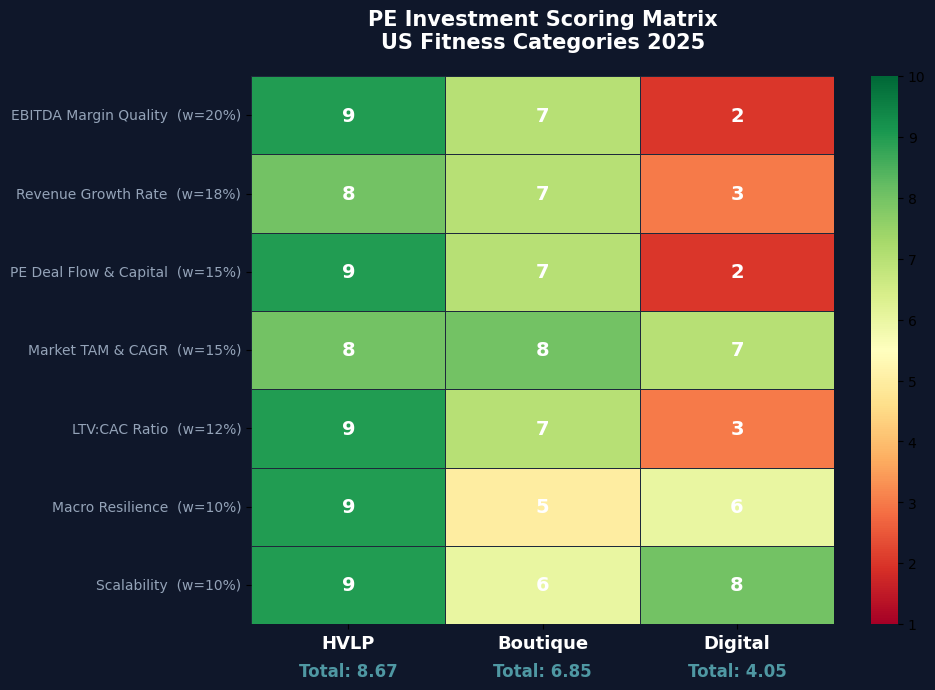

✅ Scoring heatmap saved → output/scoring_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Build dataframe for heatmap
heatmap_df = pd.DataFrame(
    score_matrix,
    index=criteria_labels,
    columns=categories
)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    vmin=1, vmax=10,
    linewidths=0.5,
    linecolor='#1e293b',
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'}
)

# Weight labels on y-axis
weighted_labels = [f"{c}  (w={w:.0%})" for c, w in zip(criteria_labels, weights)]
ax.set_yticklabels(weighted_labels, color='#94a3b8', fontsize=10, rotation=0)
ax.set_xticklabels(categories, color='white', fontsize=13, fontweight='bold')
ax.set_title('PE Investment Scoring Matrix\nUS Fitness Categories 2025',
             color='white', fontsize=15, fontweight='bold', pad=20)

# Score totals below heatmap
for i, (cat, score) in enumerate(zip(categories, total_scores)):
    ax.text(i + 0.5, len(criteria_labels) + 0.6,
            f'Total: {score:.2f}',
            ha='center', va='center',
            color='#4f98a3', fontsize=12, fontweight='bold')

plt.tight_layout()


os.makedirs("../output", exist_ok=True)
plt.savefig("../output/scoring_heatmap.png", dpi=150,
            bbox_inches='tight', facecolor='#0f172a')

plt.show()
print("✅ Scoring heatmap saved → output/scoring_heatmap.png")

## Radar/Spider Chart

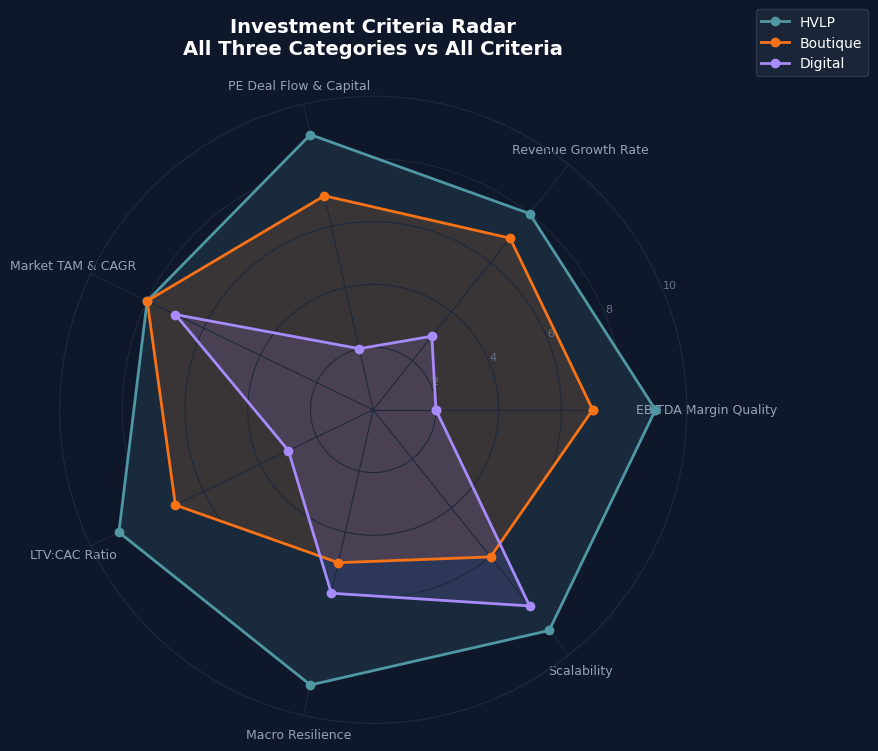

✅ Radar chart saved → output/radar_chart.png


In [7]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

labels = criteria_labels
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

colors = {'HVLP': '#4f98a3', 'Boutique': '#f97316', 'Digital': '#a78bfa'}

for cat in categories:
    vals = [scores_raw[c][cat] for c in criteria_labels]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors[cat], label=cat)
    ax.fill(angles, vals, alpha=0.15, color=colors[cat])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria_labels, color='#94a3b8', fontsize=9)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], color='#64748b', fontsize=8)
ax.grid(color='#1e293b', linewidth=0.8)
ax.spines['polar'].set_color('#1e293b')

legend = ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
                   facecolor='#1e293b', edgecolor='#334155')
for text in legend.get_texts():
    text.set_color('white')

ax.set_title('Investment Criteria Radar\nAll Three Categories vs All Criteria',
             color='white', fontsize=14, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('../output/radar_chart.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Radar chart saved → output/radar_chart.png")

## Sensitivity Analysis 

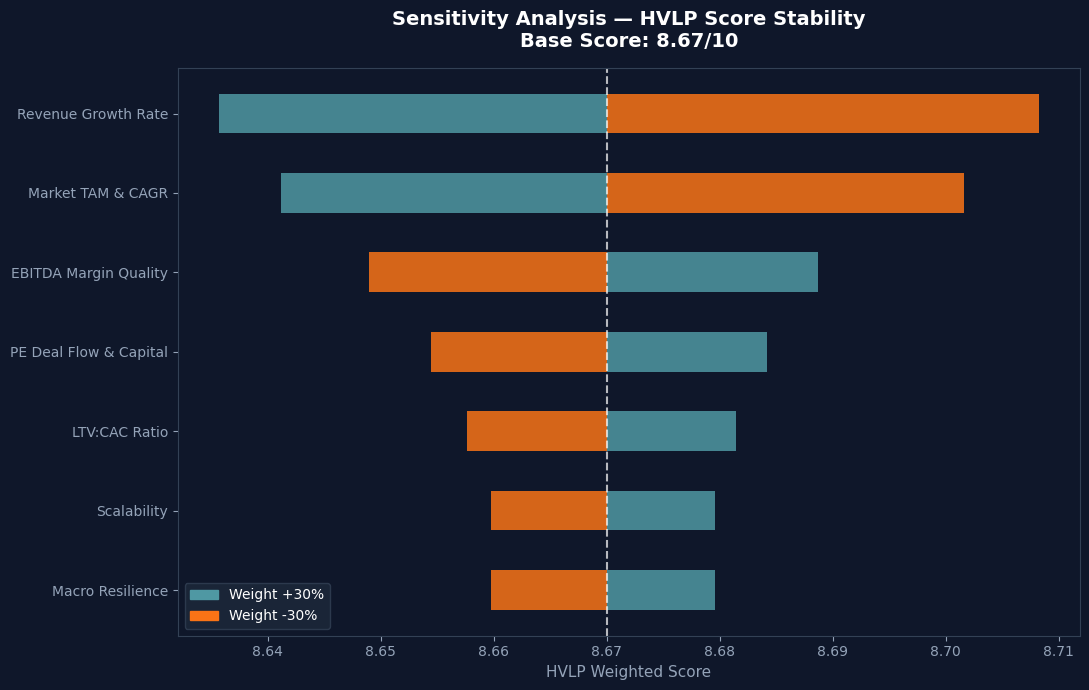

✅ Sensitivity tornado saved → output/sensitivity_tornado.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Vary each weight ±30% and record score change for HVLP (the winner)
base_hvlp = total_scores[0]
sensitivity_results = []

for i, (crit, base_w) in enumerate(criteria.items()):
    # Increase this weight by 30%, decrease all others proportionally
    new_weights_up = weights.copy()
    new_weights_up[i] = base_w * 1.30
    new_weights_up = new_weights_up / new_weights_up.sum()  # renormalise
    score_up = (score_matrix[:, 0] * new_weights_up).sum()

    new_weights_down = weights.copy()
    new_weights_down[i] = base_w * 0.70
    new_weights_down = new_weights_down / new_weights_down.sum()
    score_down = (score_matrix[:, 0] * new_weights_down).sum()

    sensitivity_results.append({
        'criterion': crit,
        'score_up': score_up,
        'score_down': score_down,
        'range': abs(score_up - score_down)
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values('range', ascending=True)

# Plot tornado
bars_up   = sens_df['score_up'] - base_hvlp
bars_down = sens_df['score_down'] - base_hvlp

y_pos = range(len(sens_df))
ax.barh(y_pos, bars_up,   left=base_hvlp, color='#4f98a3', alpha=0.85, height=0.5)
ax.barh(y_pos, bars_down, left=base_hvlp, color='#f97316', alpha=0.85, height=0.5)
ax.axvline(x=base_hvlp, color='white', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(sens_df['criterion'], color='#94a3b8', fontsize=10)
ax.set_xlabel('HVLP Weighted Score', color='#94a3b8', fontsize=11)
ax.set_title(f'Sensitivity Analysis — HVLP Score Stability\nBase Score: {base_hvlp:.2f}/10',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

up_patch   = mpatches.Patch(color='#4f98a3', label='Weight +30%')
down_patch = mpatches.Patch(color='#f97316', label='Weight -30%')
legend = ax.legend(handles=[up_patch, down_patch],
                   facecolor='#1e293b', edgecolor='#334155')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('../output/sensitivity_tornado.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Sensitivity tornado saved → output/sensitivity_tornado.png")